In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import joblib
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix, hstack
from langdetect import detect, DetectorFactory
import seaborn as sns


In [20]:
# Завантаження класифікатора
clf = joblib.load("models/logreg_classifier_tfidf_emb.pkl")

# Завантаження TF-IDF векторизатора
vectorizer = joblib.load("models/tfidf_vectorizer.pkl")

print("✅ Model and vectorizer loaded successfully!")

✅ Model and vectorizer loaded successfully!


In [21]:
print(type(clf))
print(type(vectorizer))

<class 'sklearn.multiclass.OneVsRestClassifier'>
<class 'sklearn.feature_extraction.text.TfidfVectorizer'>


In [22]:
# Read the CSV file
labeled_df = pd.read_csv("C:\\Users\\Користувач\\Desktop\\NLP_files\\labeled_df.csv", sep=';')
unlabeled_df = pd.read_csv("C:\\Users\\Користувач\\Desktop\\NLP_files\\unlabeled_df.xls", sep=';')

In [23]:
labeled_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   University Name              500 non-null    object 
 1   Review Date                  500 non-null    object 
 2   Review Text                  500 non-null    object 
 3   Timestamp                    500 non-null    object 
 4   Year                         500 non-null    int64  
 5   Attitude_Towards_Students    500 non-null    float64
 6   Campus_conditions            500 non-null    float64
 7   Corruption                   500 non-null    float64
 8   Academic_Process_Management  500 non-null    float64
 9   Education_Quality            500 non-null    float64
 10  Cleaned_Text                 500 non-null    object 
 11  Lemmatized_Text              500 non-null    object 
dtypes: float64(5), int64(1), object(6)
memory usage: 47.0+ KB


In [32]:

# ==========================================
# 1. Load input data
# ==========================================
texts = unlabeled_df["Lemmatized_Text"].tolist()

# ==========================================
# 2. Load trained model and TF-IDF vectorizer
# ==========================================
clf = joblib.load("models/logreg_classifier_tfidf_emb.pkl")
vectorizer = joblib.load("models/tfidf_vectorizer.pkl")

# ==========================================
# 3. TF-IDF transformation
# ==========================================
X_tfidf = vectorizer.transform(texts)

# ==========================================
# 4. Load sentence embeddings
# ==========================================
X_emb = np.load("C:/Users/Користувач/Desktop/NLP_files/embeddings/unlabeled_embeddings.npy")
X_emb_sparse = csr_matrix(X_emb)

# ==========================================
# 5. Combine TF-IDF features with embeddings
# ==========================================
X_combined = hstack([X_tfidf, X_emb_sparse])

# ==========================================
# 6. Predict probabilities and binary labels
# ==========================================
label_cols = [
    "Attitude_Towards_Students",
    "Campus_conditions",
    "Corruption",
    "Academic_Process_Management",
    "Education_Quality"
]

# Get class probabilities for each label
y_prob = clf.predict_proba(X_combined)  # shape: (num_samples, num_labels)

# Apply threshold to get binary predictions
threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

# ==========================================
# 7. Add predictions and probabilities to DataFrame
# ==========================================
pred_df = pd.DataFrame(y_pred, columns=label_cols)
prob_df = pd.DataFrame(y_prob, columns=[f"{c}_prob" for c in label_cols])

unlabeled_df[label_cols] = pred_df
unlabeled_df[[f"{c}_prob" for c in label_cols]] = prob_df

# ==========================================
# 8. Save results (optional)
# ==========================================
# Save labeled data for further analysis or inspection
unlabeled_df.to_csv("unlabeled_with_predictions.csv", index=False)

print("✅ Predictions added to DataFrame and saved to 'unlabeled_with_predictions.csv'.")





✅ Predictions added to DataFrame and saved to 'unlabeled_with_predictions.csv'.


In [33]:
# List of label columns
label_cols = [
    "Attitude_Towards_Students",
    "Campus_conditions",
    "Corruption",
    "Academic_Process_Management",
    "Education_Quality"
]

# Function to get all assigned labels (where value == 1)
def get_labels(row):
    return [col for col in label_cols if row[col] == 1]

# Add a new column with human-readable label lists
unlabeled_df["Predicted_Labels"] = unlabeled_df.apply(get_labels, axis=1)

# Display 20 example reviews with predicted labels and probabilities
for i, row in unlabeled_df.head(20).iterrows():
    print(f"\n🔹 Review #{i+1}:")
    print(f"📝 {row['Review Text']}\n")

    # Extract predicted labels
    labels = row["Predicted_Labels"]

    if labels:
        print("🏷️ Labels and probabilities:")
        for label in labels:
            prob_col = f"{label}_prob"
            prob = row[prob_col] if prob_col in unlabeled_df.columns else None
            print(f"   - {label}: {prob:.3f}")
    else:
        print("🏷️ Labels: —")

    print("-" * 90)



🔹 Review #1:
📝 1. зміст навчання і предмети не відповідають спеціальності. Навіщо Вища математика для спеціальності Менеджменту.2. Навчання формальне бо хто за копійки буде старатись навчати.3. Проросійські викладачи як Пазюра.

🏷️ Labels and probabilities:
   - Education_Quality: 0.974
------------------------------------------------------------------------------------------

🔹 Review #2:
📝 Три года обучения дистанционно, хотя в других вузах студенты ходят на пары полноценно. Лекции даже дистанционно не хотят проводить, просто скидывают задание и все! За что мы платим деньги???!

🏷️ Labels and probabilities:
   - Academic_Process_Management: 0.970
------------------------------------------------------------------------------------------

🔹 Review #3:
📝 Працюють лише старі як перед смертю, або ті кого нікуди більш не беруть. Зарплати копічані, якість всього така сама.

🏷️ Labels and probabilities:
   - Education_Quality: 0.686
----------------------------------------------------------

In [34]:
# ==========================================
# 🧩 Merge labeled and model-labeled datasets
# ==========================================

# We combine both DataFrames (manually labeled + model-labeled)
# to perform further analysis on the entire dataset.
combined_df = pd.concat([labeled_df, unlabeled_df], ignore_index=True)

print(f"✅ Combined dataset created: {combined_df.shape[0]} rows, {combined_df.shape[1]} columns.")


✅ Combined dataset created: 2306 rows, 18 columns.


In [35]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2306 entries, 0 to 2305
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   University Name                   2306 non-null   object 
 1   Review Date                       500 non-null    object 
 2   Review Text                       2306 non-null   object 
 3   Timestamp                         2306 non-null   object 
 4   Year                              2306 non-null   int64  
 5   Attitude_Towards_Students         2306 non-null   float64
 6   Campus_conditions                 2306 non-null   float64
 7   Corruption                        2306 non-null   float64
 8   Academic_Process_Management       2306 non-null   float64
 9   Education_Quality                 2306 non-null   float64
 10  Cleaned_Text                      2306 non-null   object 
 11  Lemmatized_Text                   2306 non-null   object 
 12  Attitu

In [36]:
# Convert 'Timestamp' to datetime format
# Errors are coerced to NaT (missing value) if the format doesn't match
combined_df["Timestamp"] = pd.to_datetime(combined_df["Timestamp"], errors="coerce")

In [47]:
# 🗑️ Remove 'Review Date' column
# ==========================================
combined_df = combined_df.drop(columns=["Review Date"])
combined_df = combined_df.drop(columns=[col for col in combined_df.columns if col.endswith("_prob")])
combined_df = combined_df.drop(columns=["Predicted_Labels"])

In [48]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2306 entries, 0 to 2305
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   University Name              2306 non-null   object        
 1   Review Text                  2306 non-null   object        
 2   Timestamp                    2306 non-null   datetime64[ns]
 3   Year                         2306 non-null   int64         
 4   Attitude_Towards_Students    2306 non-null   float64       
 5   Campus_conditions            2306 non-null   float64       
 6   Corruption                   2306 non-null   float64       
 7   Academic_Process_Management  2306 non-null   float64       
 8   Education_Quality            2306 non-null   float64       
 9   Cleaned_Text                 2306 non-null   object        
 10  Lemmatized_Text              2306 non-null   object        
 11  Language                     2306 non-null 

In [49]:
# Detect the language of each review and create a new column 'Language'
DetectorFactory.seed = 42  # для стабільних результатів

# Function to safely detect language
def detect_language(text):
    try:
        return detect(text)
    except:
        return "unknown"

# Create a new column 'Language'
combined_df["Language"] = combined_df["Review Text"].apply(detect_language)

# Check results
print(combined_df[["Review Text", "Language"]].head(10))

                                         Review Text Language
0  По информационному праву Токарева Ксения Серге...       ru
1  Людоньки це *****. Моя дочку поселили в кімнат...       uk
2  Шановні вступники, якщо ви хочете зберегти сво...       uk
3  Советую ПРОКУРАТУРЕ проверить отдел закупок чт...       ru
4  Не знаю як і хто а я звязав своє життя з НАУ я...       uk
5  Тут до першого курсу відносяться як до дурнів ...       uk
6  Первокурсников заставляют мыть туалеты, не пон...       ru
7  Начну с того, что выбранной специальностью дов...       ru
8  НАУ Киев, 5 курс ! Оплатив семестре 9 тысяч! П...       ru
9  Поступил сюда после колледжа на второй курс на...       ru


In [50]:
combined_df.head()

,University Name,Review Text,Timestamp,Year,Attitude_Towards_Students,Campus_conditions,Corruption,Academic_Process_Management,Education_Quality,Cleaned_Text,Lemmatized_Text,Language
0,University_1,По информационному праву Токарева Ксения Серге...,2021-12-09,2021,1.0,0.0,0.0,0.0,0.0,по информационному праву токарева ксения серге...,информационный право токарев ксения сергеевич ...,ru
1,University_1,Людоньки це *****. Моя дочку поселили в кімнат...,2021-08-25,2021,0.0,1.0,0.0,0.0,0.0,людоньки це моя дочку поселили в кімнату з дів...,людоньки дочка поселити кімната дівчина NUM хл...,uk
2,University_1,"Шановні вступники, якщо ви хочете зберегти сво...",2019-06-08,2019,0.0,1.0,0.0,0.0,1.0,шановні вступники якщо ви хочете зберегти свої...,шановний вступник хотіти зберегти нерв здоров’...,uk
3,University_1,Советую ПРОКУРАТУРЕ проверить отдел закупок чт...,2019-05-25,2019,0.0,0.0,1.0,0.0,0.0,советую прокуратуре проверить отдел закупок чт...,советовать прокуратура проверить отдел закупка...,ru
4,University_1,Не знаю як і хто а я звязав своє життя з НАУ я...,2019-05-19,2019,0.0,1.0,0.0,0.0,1.0,не знаю як і хто а я звязав своє життя з нау я...,не знати звязати життя студент гроші коментар ...,uk


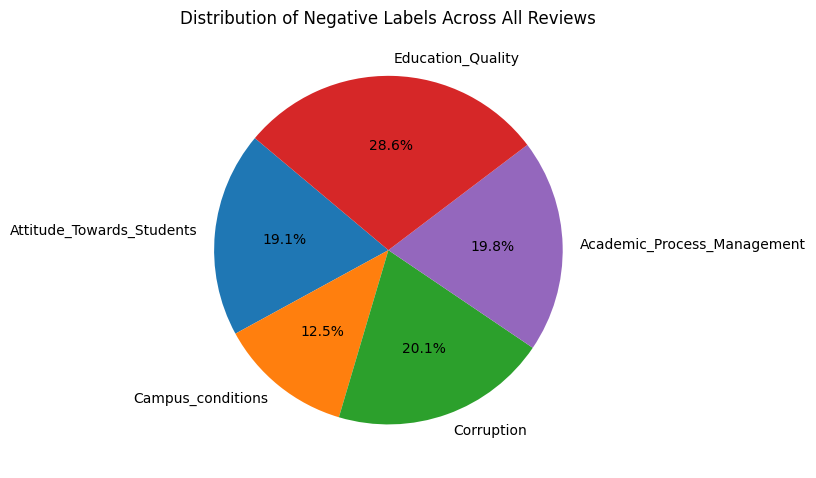

In [53]:

# List of label columns
label_cols = [
    "Attitude_Towards_Students",
    "Campus_conditions",
    "Corruption",
    "Academic_Process_Management",
    "Education_Quality"
]

# Count total positive labels for each category across all reviews
label_sums = combined_df[label_cols].sum()

# Colors for pie chart
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd", "#d62728"]

# Plot pie chart
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(
    label_sums,
    labels=label_cols,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors
)
ax.set_title("Distribution of Negative Labels Across All Reviews")
plt.tight_layout()
plt.show()


### 📊 Key Insights from Overall Negative Feedback

- **Education Quality:** The largest share of negative feedback is related to **Education Quality**, accounting for **28.6%** of all negative labels.  
- **Attitude Towards Students, Corruption, Academic Process Management:** These three categories have roughly similar shares, each contributing about **19–20%** of negative labels.  
- **Campus Conditions:** The smallest proportion of complaints is related to **Campus Conditions**, accounting for **12.5%**.


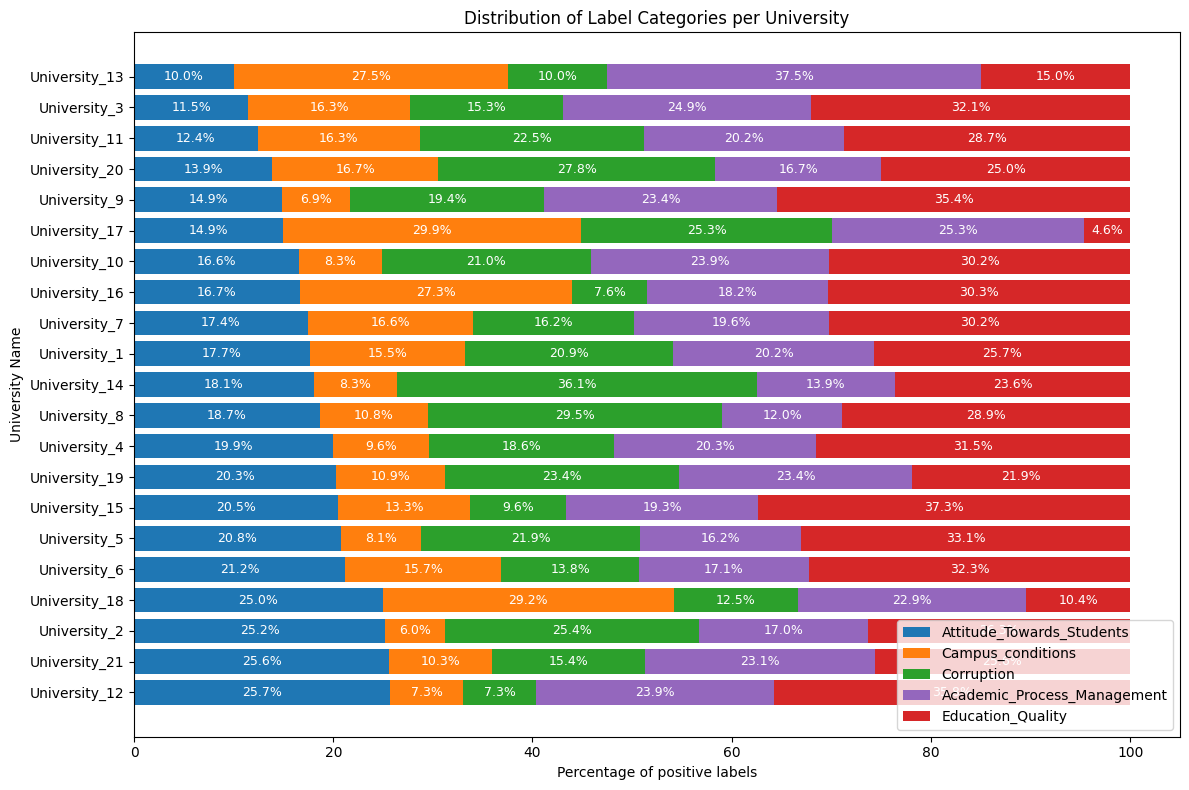

In [52]:

# List of label columns
label_cols = [
    "Attitude_Towards_Students",
    "Campus_conditions",
    "Corruption",
    "Academic_Process_Management",
    "Education_Quality"
]

# Aggregate data by university
agg_df = combined_df.groupby("University Name")[label_cols].sum()

# Normalize by total positive labels per university
agg_pct = agg_df.div(agg_df.sum(axis=1), axis=0) * 100  # convert to percentages

# Sort universities by total labels (optional)
agg_pct = agg_pct.sort_values(by=label_cols[0], ascending=False)

# Colors for each category
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd", "#d62728"]

# Plot
fig, ax = plt.subplots(figsize=(12, 8))

bottom = np.zeros(len(agg_pct))
for i, col in enumerate(label_cols):
    ax.barh(
        agg_pct.index,
        agg_pct[col],
        left=bottom,
        color=colors[i],
        label=col
    )
    # Add text inside bars
    for j, val in enumerate(agg_pct[col]):
        if val > 0:
            ax.text(bottom[j] + val/2, j, f"{val:.1f}%", va='center', ha='center', color='white', fontsize=9)
    bottom += agg_pct[col].values

ax.set_xlabel("Percentage of positive labels")
ax.set_ylabel("University Name")
ax.set_title("Distribution of Label Categories per University")
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 📌 Analysis of Key Problems by Universities

- **Attitude Towards Students:** The worst rating was observed in **university_12**.  
- **Campus Conditions:** The poorest conditions were reported in **university_17**.  
- **Corruption:** The highest level of corruption was found in **university_14**.  
- **Academic Process Management:** The least effective management of the academic process was noted in **university_13**.  
- **Education Quality:** The lowest quality of education was recorded in **university_15**.  

> These findings are based on the proportion of negative labels assigned to each category per university.


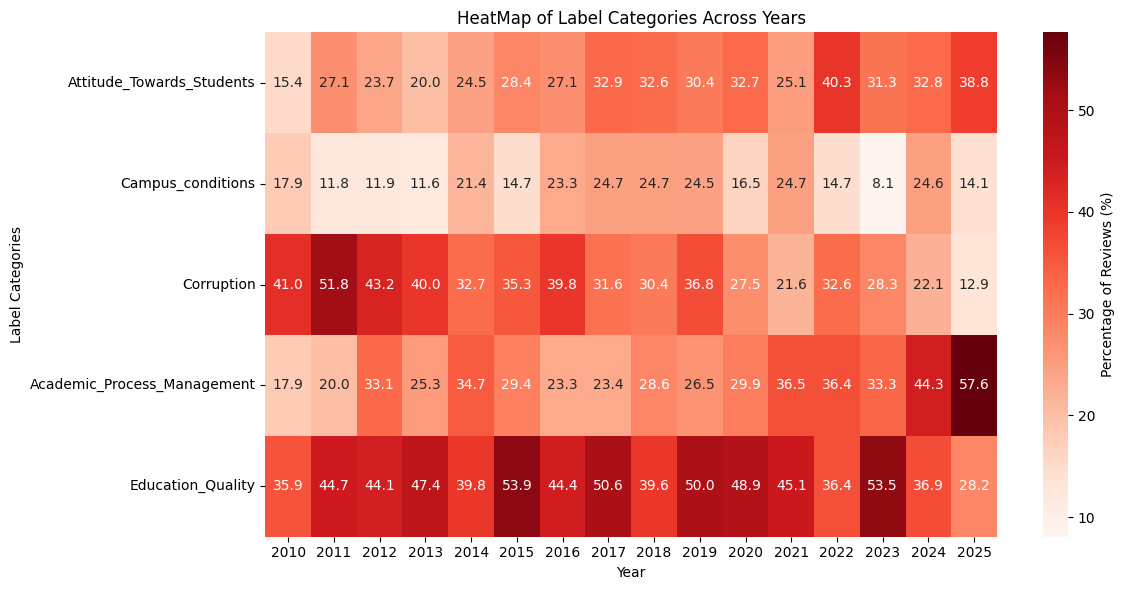

In [68]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# List of label columns
label_cols = [
    "Attitude_Towards_Students",
    "Campus_conditions",
    "Corruption",
    "Academic_Process_Management",
    "Education_Quality"
]

# Ensure we have a 'Year' column (from Timestamp if necessary)
# combined_df['Year'] = combined_df['Timestamp'].dt.year

# Group by Year and sum labels
agg_df = combined_df.groupby("Year")[label_cols].sum()

# Count total reviews per year
reviews_per_year = combined_df.groupby("Year").size()

# Convert to fraction of reviews (percentage)
agg_pct = agg_df.div(reviews_per_year, axis=0) * 100

# Transpose for heatmap (rows=categories, columns=years)
heatmap_data = agg_pct.T

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data,
    annot=True,        # show percentages
    fmt=".1f",
    cmap="Reds",
    cbar_kws={'label': 'Percentage of Reviews (%)'}
)
plt.title("HeatMap of Label Categories Across Years")
plt.ylabel("Label Categories")
plt.xlabel("Year")
plt.tight_layout()
plt.show()


### 📊 Key Insights from Negative Feedback Across Years

- **Attitude Towards Students:** From 2017 onwards, complaints about student treatment have noticeably increased.  
- **Corruption:** The highest frequency of complaints occurred during 2010–2019.  
- **Academic Process Management:** Complaints peaked starting in 2021, reaching a particularly high share of **57.6%** of all reviews, likely related to the organization of the academic process during the war period.  
- **Education Quality:** Throughout all years, there has been a consistently high number of complaints regarding the quality of education.  


C:\Users\Користувач\AppData\Local\Temp\ipykernel_28560\3976112260.py:33: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ax.imshow(dominant_color_matrix.applymap(lambda x: np.array([int(x[i:i+2],16)/255 for i in (1,3,5)])).values.tolist(), aspect='auto')


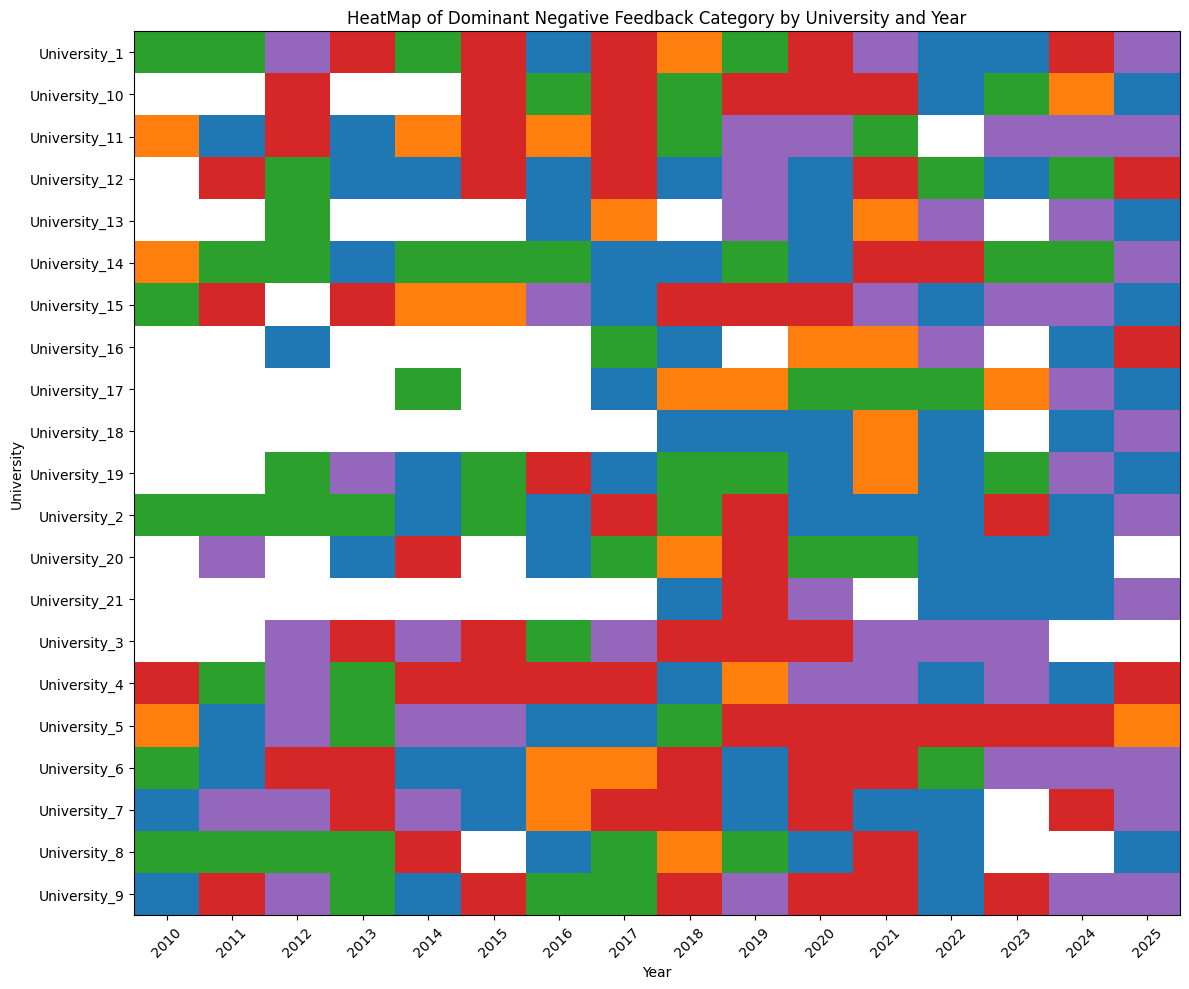

In [69]:

# List of label columns
label_cols = [
    "Attitude_Towards_Students",
    "Campus_conditions",
    "Corruption",
    "Academic_Process_Management",
    "Education_Quality"
]

# Custom colors for each category
base_colors_hex = ["#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd", "#d62728"]
category_colors = dict(zip(label_cols, base_colors_hex))

# Ensure 'Year' column exists
# combined_df['Year'] = combined_df['Timestamp'].dt.year

# Aggregate: count sum of labels by University and Year
agg_df = combined_df.groupby(['University Name', 'Year'])[label_cols].sum()

# Calculate fraction per university-year
reviews_per_uni_year = combined_df.groupby(['University Name', 'Year']).size()
agg_frac = agg_df.div(reviews_per_uni_year, axis=0)  # fraction 0-1

# Determine dominant category per university-year
dominant_category = agg_frac.idxmax(axis=1)  # which label has max fraction
dominant_color = dominant_category.map(category_colors)

# Pivot for heatmap: rows=universities, columns=years
dominant_color_matrix = dominant_color.unstack().fillna('#ffffff')  # fill NaN with white

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(dominant_color_matrix.applymap(lambda x: np.array([int(x[i:i+2],16)/255 for i in (1,3,5)])).values.tolist(), aspect='auto')

# Set ticks
ax.set_xticks(np.arange(len(dominant_color_matrix.columns)))
ax.set_xticklabels(dominant_color_matrix.columns, rotation=45)
ax.set_yticks(np.arange(len(dominant_color_matrix.index)))
ax.set_yticklabels(dominant_color_matrix.index)

ax.set_xlabel("Year")
ax.set_ylabel("University")
ax.set_title("HeatMap of Dominant Negative Feedback Category by University and Year")
plt.tight_layout()
plt.show()


### 📊 Insights on Dominant Negative Feedback by University and Year

- Overall, there is **no clear long-term trend** for any particular university where a single problem consistently dominates over the years.  
- One notable observation is **university_5**, where starting from 2019, the majority of complaints are related to **Education Quality**.


Language
ru    50.065132
uk    49.934868
Name: count, dtype: float64


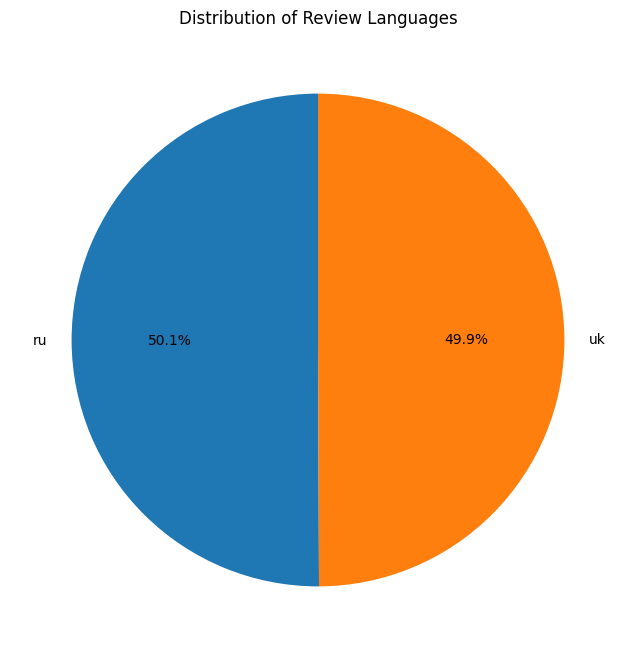

In [74]:

# ------------------------------
# 1️⃣ Detect the language of each review
# ------------------------------
combined_df['Language'] = combined_df['Review Text'].apply(lambda x: detect(str(x)))

# ------------------------------
# 2️⃣ Remove Bulgarian reviews
# ------------------------------
combined_df = combined_df[combined_df['Language'] != 'bg'].copy()  # 'bg' = Bulgarian

# ------------------------------
# 3️⃣ Calculate language distribution
# ------------------------------
language_counts = combined_df['Language'].value_counts()
language_pct = (language_counts / language_counts.sum()) * 100

print(language_pct)

# ------------------------------
# 4️⃣ Plot a pie chart of language distribution
# ------------------------------
plt.figure(figsize=(8,8))
language_pct.plot.pie(
    autopct='%1.1f%%',          # show percentage
    startangle=90,               # start from top
    colors=["#1f77b4", "#ff7f0e", "#2ca02c"],  # custom saturated colors
)
plt.ylabel("")
plt.title("Distribution of Review Languages")
plt.show()


### 🌐 Language Distribution of Reviews

- Approximately **50% of reviews are in Ukrainian**.  
- Approximately **50% of reviews are in Russian**.  
- There are no other significant languages after removing the single Bulgarian review.


(0.0, 100.0)

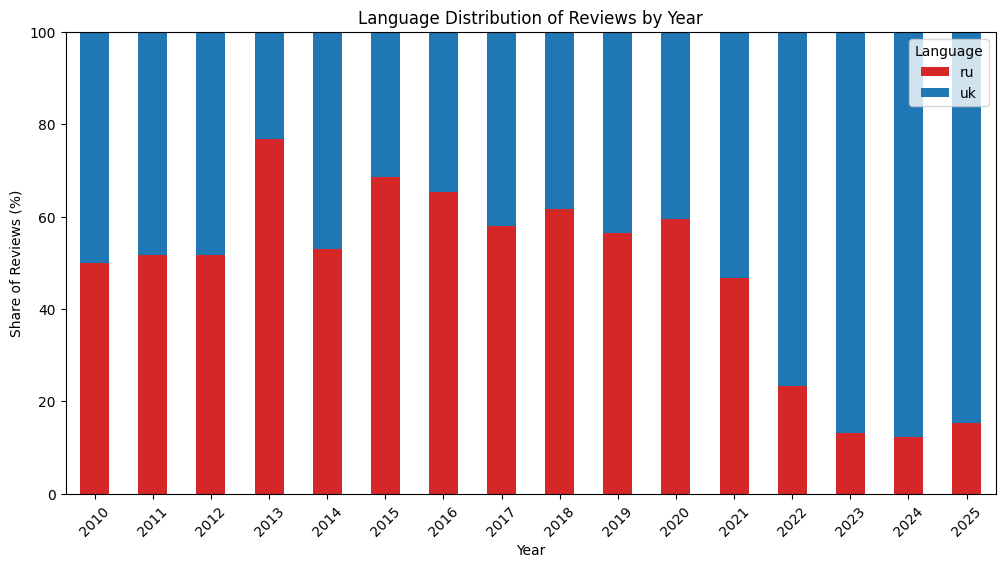

In [82]:

# ------------------------------
# 1️⃣ Count reviews per language per year
# ------------------------------
lang_year_counts = combined_df.groupby(['Year', 'Language']).size().unstack(fill_value=0)

# ------------------------------
# 2️⃣ Convert counts to percentages
# ------------------------------
lang_year_pct = lang_year_counts.div(lang_year_counts.sum(axis=1), axis=0) * 100

# ------------------------------
# 3️⃣ Sort years
# ------------------------------
lang_year_pct = lang_year_pct.sort_index()

# ------------------------------
# 4️⃣ Define colors
# ------------------------------
colors = {'uk': '#1f77b4', 'ru': '#d62728'}  # blue for Ukrainian, red for Russian

# ------------------------------
# 5️⃣ Plot stacked bar chart
# ------------------------------
ax = lang_year_pct.plot(
    kind='bar',
    stacked=True,
    color=[colors.get(c, '#d3d3d3') for c in lang_year_pct.columns],
    figsize=(12, 6)
)

plt.ylabel("Share of Reviews (%)")
plt.xlabel("Year")
plt.title("Language Distribution of Reviews by Year")
plt.legend(title="Language")
plt.xticks(rotation=45)
plt.ylim(0, 100)

# ------------------------------
# 6️⃣ Annotate bars with percentages (above each section)
# ------------------------------



# 🗣️ Language Dynamics of Reviews Over Time

- In **2010–2012**, the distribution of review languages was roughly **50/50 between Ukrainian and Russian**.  
- Between **2013 and 2020**, reviews written in **Russian** became more prevalent.  
- Starting from **2022 and onward**, the majority of reviews have been written in **Ukrainian**.  
  This shift likely reflects broader sociolinguistic changes in society, where more users consciously choose to communicate in Ukrainian in the context of recent events and the ongoing war.
